# CPC-Tiny (paper-faithful)

This is the **paper-faithful** version of CPC (van den Oord et al., 2018, §3.2). Two changes vs `4_CPC` :

1. **Encoder = CNN applied per patch.** Each 4×4 patch is encoded **independently** by a small CNN (a conv with `kernel=stride=4`, then 1×1 convs). There is **no cross-patch interaction in the encoder**, so the whole image can be encoded in one pass with **no leakage** — no need to split into halves.

2. **AR model = causal row-GRU (PixelRNN-style).** Instead of a Transformer, a GRU scans the grid **top-to-bottom**, column by column. The context for a column summarizes only the rows above (causal). The paper states a *"convolutional row-GRU PixelRNN gave similar results"* to the PixelCNN.

Prediction is **down each column** : from the context built on the top rows, predict the latents of the bottom rows with one bilinear head $W_k$ per step. Loss = InfoNCE with batch negatives, exactly as before.

Everything else (datasets, linear probe, full fine-tune) is identical to `4_CPC`.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import os

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "DATA"))
CKPT_DIR = './checkpoints/5_CPC_paper'
os.makedirs(CKPT_DIR, exist_ok=True)

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device = {device}")

device = cuda


---
# 0. Dataset

STL-10 unlabeled (100k train / 8k test) for self-supervised pre-training. CIFAR-10 (50k train / 10k test) for downstream evaluation (linear probe + fine-tune).

In [2]:
BATCH_SIZE = 128
IMG_SIZE   = 32
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

pretrain_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
train_probe_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

pretrain_set = torchvision.datasets.STL10(root=DATA_DIR, split='unlabeled', download=True, transform=pretrain_tf)
train_dataset = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_probe_tf)
test_dataset  = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_tf)

pretrain_loader = DataLoader(pretrain_set,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
train_loader    = DataLoader(train_dataset,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader     = DataLoader(test_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_img, _ = train_dataset[0]
CHANNELS, H, W = sample_img.shape
NUM_CLASSES    = len(train_dataset.classes)

print("── Pre-training (STL-10, self-supervised) ──")
print(f"  train (unlabeled) : {len(pretrain_set):>6}")
print()
print("── Downstream (CIFAR-10, supervised) ──")
print(f"  train             : {len(train_dataset):>6}")
print(f"  test              : {len(test_dataset):>6}")
print()
print(f"CIFAR-10 classes : {train_dataset.classes}")

── Pre-training (STL-10, self-supervised) ──
  train (unlabeled) : 100000

── Downstream (CIFAR-10, supervised) ──
  train             :  50000
  test              :  10000

CIFAR-10 classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
# 1. CPC architecture (paper-faithful)

### Encoder $g_{\text{enc}}$ : per-patch CNN

A conv with `kernel=stride=4` maps each 4×4 patch to one vector **independently** (no overlap → no cross-patch mixing), followed by `ENC_LAYERS` 1×1 convs of width `ENC_HIDDEN` (per-position, still independent), then a 1×1 conv to `D_MODEL`. The whole 32×32 image is encoded in one pass into an 8×8 grid of latents, with **zero leakage** between patches. The width/depth are chosen so the total model (~1.67M params) **matches the ViT version** `4_CPC_vit` for a fair comparison.

| Step | Operation | Shape |
|---|---|---|
| Input | image | $(B, 3, 32, 32)$ |
| Conv `k=s=4` | per-patch projection | $(B, \text{ENC\_HIDDEN}, 8, 8)$ |
| `ENC_LAYERS` × 1×1 conv + GELU | per-position depth | $(B, \text{ENC\_HIDDEN}, 8, 8)$ |
| 1×1 conv → `D_MODEL` + LayerNorm | project to D | $(B, 8, 8, 128)$ |

### AR model $g_{\text{ar}}$ : causal row-GRU (PixelRNN-style)

A GRU (`GRU_LAYERS` layers) scans the **context rows top-to-bottom, down each column**. The final hidden state of a column summarizes only the rows above it (causal). Output : one context vector per column. The paper states a *"convolutional row-GRU PixelRNN gave similar results"* to the PixelCNN.

| Step | Operation | Shape |
|---|---|---|
| Context rows | top `n_context_rows` of the grid | $(B, 4, 8, D)$ |
| GRU down each column | causal scan over rows | $(B, 8, D)$ context per column |

### Prediction + InfoNCE

For each future row $k$ and each column $g$ : predict $W_k c_g$ and contrast it against the true latent $z_{k,g}$ of that column/row, with the same-position patches of the other batch images as negatives.

| Hyperparameter | Symbol | Value |
|---|---|---|
| Model dim | `d_model` | 128 |
| Encoder hidden width | `enc_hidden` | 512 |
| Encoder 1×1 layers | `enc_layers` | 5 |
| AR GRU layers | `gru_layers` | 2 |
| Patch size | `patch_size` | 4 |
| Grid | `grid_size` | 8 |
| Context rows | `n_context_rows` | 4 |
| Rows to predict | `n_predict` | 4 |

---

![CPC paper-faithful architecture](figures/cpc_paper_architecture.png)

## Hyperparameters

In [3]:
PATCH_SIZE  = 4
GRID_SIZE   = IMG_SIZE // PATCH_SIZE     # 8
N_PATCHES   = GRID_SIZE ** 2             # 64

D_MODEL    = 128
DROPOUT    = 0.1

# per-patch CNN encoder sized to ~match the ViT version (4_CPC_vit ~ 1.67M params)
ENC_HIDDEN = 512    # internal width of the 1x1 convs
ENC_LAYERS = 5      # number of 1x1 conv layers (per-position depth)
GRU_LAYERS = 2      # AR row-GRU depth

N_CONTEXT_ROWS = 4
N_PREDICT      = GRID_SIZE - N_CONTEXT_ROWS   # 4

PRETRAIN_EPOCHS = 20
PROBE_EPOCHS    = 60
FT_EPOCHS       = 60

print(f"grid           = {GRID_SIZE} x {GRID_SIZE}")
print(f"context rows   = {N_CONTEXT_ROWS}")
print(f"rows to predict= {N_PREDICT}")

grid           = 8 x 8
context rows   = 4
rows to predict= 4


In [4]:
def unnormalize(img):
    mean = torch.tensor(MEAN).view(3, 1, 1).to(img.device)
    std  = torch.tensor(STD).view(3, 1, 1).to(img.device)
    return (img * std + mean).clamp(0, 1)


class PatchCNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.proj   = nn.Conv2d(CHANNELS, ENC_HIDDEN, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)  # per-patch
        self.blocks = nn.ModuleList([nn.Conv2d(ENC_HIDDEN, ENC_HIDDEN, kernel_size=1) for _ in range(ENC_LAYERS)])
        self.out    = nn.Conv2d(ENC_HIDDEN, D_MODEL, kernel_size=1)
        self.norm   = nn.LayerNorm(D_MODEL)

    def forward(self, images):                  # (B, 3, 32, 32)
        x = F.gelu(self.proj(images))           # (B, ENC_HIDDEN, 8, 8)  each position = one 4x4 patch
        for blk in self.blocks:
            x = F.gelu(blk(x))                  # 1x1 conv : per-position, no mixing
        x = self.out(x)                         # (B, D_MODEL, 8, 8)
        x = x.permute(0, 2, 3, 1)               # (B, 8, 8, D)  [row, col, D]
        x = self.norm(x)                        # LayerNorm over D at each position (no spatial mix)
        return x


class ARModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(D_MODEL, D_MODEL, num_layers=GRU_LAYERS, batch_first=True)

    def forward(self, z_ctx):                   # (B, n_context_rows, grid, D)
        B, R, G, D = z_ctx.shape
        x = z_ctx.permute(0, 2, 1, 3).reshape(B * G, R, D)   # (B*G, R, D) sequence over rows per column
        _, h = self.gru(x)                                   # h: (GRU_LAYERS, B*G, D)
        c = h[-1].reshape(B, G, D)                           # last layer hidden -> (B, G, D) context per column
        return c


class CPC(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = PatchCNN()
        self.ar      = ARModel()
        self.W = nn.ModuleList([nn.Linear(D_MODEL, D_MODEL, bias=False) for _ in range(N_PREDICT)])

    def forward(self, images):
        z = self.encoder(images)                       # (B, 8, 8, D)  whole image, per-patch
        z_ctx = z[:, :N_CONTEXT_ROWS, :, :]            # (B, 4, 8, D)  top rows
        z_tgt = z[:, N_CONTEXT_ROWS:, :, :]            # (B, 4, 8, D)  bottom rows
        c = self.ar(z_ctx)                             # (B, 8, D)  context per column

        B = images.shape[0]
        labels = torch.arange(B, device=images.device)
        loss = 0.0
        for k in range(N_PREDICT):
            pred   = self.W[k](c)                      # (B, 8, D)  prediction for row k, each column
            target = z_tgt[:, k, :, :]                 # (B, 8, D)  true row k
            li = 0.0
            for g in range(GRID_SIZE):
                logits = pred[:, g, :] @ target[:, g, :].T   # (B, B)
                li = li + F.cross_entropy(logits, labels)
            loss = loss + li / GRID_SIZE
        return loss / N_PREDICT


cpc = CPC().to(device)

params = sum(p.numel() for p in cpc.parameters())

# Theoretical parameter count

enc_proj   = CHANNELS * ENC_HIDDEN * PATCH_SIZE**2 + ENC_HIDDEN      # conv k=s=4
enc_blocks = ENC_LAYERS * (ENC_HIDDEN * ENC_HIDDEN + ENC_HIDDEN)     # ENC_LAYERS x 1x1 conv
enc_out    = ENC_HIDDEN * D_MODEL + D_MODEL                          # 1x1 conv -> D_MODEL
enc_norm   = 2 * D_MODEL                                             # LayerNorm
encoder_params = enc_proj + enc_blocks + enc_out + enc_norm

gru_per_layer = 6 * D_MODEL * D_MODEL + 6 * D_MODEL
ar_params = GRU_LAYERS * gru_per_layer

w_params = N_PREDICT * (D_MODEL * D_MODEL)

params_th = encoder_params + ar_params + w_params

print(f"encoder (CNN) params : {encoder_params:,}")
print(f"AR (GRU) params      : {ar_params:,}")
print(f"W_k params           : {w_params:,}")
print(f"empirical : {params:,}")
print(f"theory    : {params_th:,}")
print(f"match     : {params == params_th}")

encoder (CNN) params : 1,404,288
AR (GRU) params      : 198,144
W_k params           : 65,536
empirical : 1,667,968
theory    : 1,667,968
match     : True


---
# 2. Pre-training on STL-10

In [5]:
PRETRAIN_LR = 1e-4

optimizer = torch.optim.AdamW(cpc.parameters(), lr=PRETRAIN_LR, weight_decay=0.05)

pretrain_losses = []
best_loss = float('inf')

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    cpc.train()
    total, n = 0.0, 0
    for imgs, _ in pretrain_loader:
        imgs = imgs.to(device)
        loss = cpc(imgs)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item() * imgs.size(0); n += imgs.size(0)
    avg = total / n
    pretrain_losses.append(avg)
    print(f"Pre-train epoch {epoch:2d}/{PRETRAIN_EPOCHS} | InfoNCE loss {avg:.4f}")

    torch.save({'epoch': epoch, 'model': cpc.state_dict(), 'losses': pretrain_losses},
               os.path.join(CKPT_DIR, 'cpc_last.pt'))
    if avg < best_loss:
        best_loss = avg
        torch.save({'epoch': epoch, 'model': cpc.state_dict(), 'losses': pretrain_losses},
                   os.path.join(CKPT_DIR, 'cpc_best.pt'))
        print(f"  -> best checkpoint saved (loss {best_loss:.4f})")

Pre-train epoch  1/20 | InfoNCE loss 3.9143
  -> best checkpoint saved (loss 3.9143)
Pre-train epoch  2/20 | InfoNCE loss 3.5091
  -> best checkpoint saved (loss 3.5091)
Pre-train epoch  3/20 | InfoNCE loss 3.3624
  -> best checkpoint saved (loss 3.3624)
Pre-train epoch  4/20 | InfoNCE loss 3.2868
  -> best checkpoint saved (loss 3.2868)
Pre-train epoch  5/20 | InfoNCE loss 3.2278
  -> best checkpoint saved (loss 3.2278)
Pre-train epoch  6/20 | InfoNCE loss 3.1827
  -> best checkpoint saved (loss 3.1827)
Pre-train epoch  7/20 | InfoNCE loss 3.1428
  -> best checkpoint saved (loss 3.1428)
Pre-train epoch  8/20 | InfoNCE loss 3.1024
  -> best checkpoint saved (loss 3.1024)
Pre-train epoch  9/20 | InfoNCE loss 3.0615
  -> best checkpoint saved (loss 3.0615)
Pre-train epoch 10/20 | InfoNCE loss 3.0209
  -> best checkpoint saved (loss 3.0209)
Pre-train epoch 11/20 | InfoNCE loss 2.9838
  -> best checkpoint saved (loss 2.9838)
Pre-train epoch 12/20 | InfoNCE loss 2.9536
  -> best checkpoint 

---
# 3. Encoder wrapper for probe / fine-tune

The per-patch CNN encodes the whole image with no leakage, so for downstream tasks we simply encode the full image and mean-pool the 64 patch features (no half-split needed).

In [6]:
class CPCEncoder(nn.Module):
    
    def __init__(self, cpc):
        super().__init__()
        self.encoder = cpc.encoder

    def forward(self, images):
        z = self.encoder(images)          # (B, 8, 8, D)
        z = z.flatten(1, 2)               # (B, 64, D)
        return z.mean(dim=1)              # (B, D)


def build_cpc_from_checkpoint():
    m = CPC().to(device)
    ckpt = torch.load(os.path.join(CKPT_DIR, 'cpc_best.pt'), map_location=device)
    m.load_state_dict(ckpt['model'])
    return m

In [7]:
def slope_per_epoch(values, window=5):
    if len(values) < 2:
        return float('inf')
    w = min(window, len(values))
    y = np.array(values[-w:]); x = np.arange(w)
    return float(np.polyfit(x, y, 1)[0])


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

---
# 4. Linear probe on CIFAR-10

Freeze the encoder, train only a linear classifier head on the mean-pooled feature.

In [8]:
class LinearProbe(nn.Module):
    def __init__(self, encoder, num_classes, d_model):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Linear(d_model, num_classes)
        for p in self.encoder.parameters():
            p.requires_grad = False

    def forward(self, images):
        with torch.no_grad():
            h = self.encoder(images)
        return self.head(h)


probe = LinearProbe(CPCEncoder(build_cpc_from_checkpoint()), NUM_CLASSES, D_MODEL).to(device)

params    = sum(p.numel() for p in probe.head.parameters())
params_th = D_MODEL * NUM_CLASSES + NUM_CLASSES
print(f"trainable (head) empirical : {params:,}")
print(f"trainable (head) theory    : {params_th:,}")
print(f"match                      : {params == params_th}")

trainable (head) empirical : 1,290
trainable (head) theory    : 1,290
match                      : True


In [9]:
PROBE_LR = 1e-3

optimizer = torch.optim.AdamW(probe.head.parameters(), lr=PROBE_LR, weight_decay=0.0)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
probe_train_losses, probe_test_losses = [], []
probe_train_accs,   probe_test_accs   = [], []
probe_best_acc = 0.0

for epoch in range(1, PROBE_EPOCHS + 1):
    probe.train(); probe.encoder.eval()
    tr_loss, tr_acc = train_one_epoch(probe, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(probe, test_loader, criterion)
    probe_train_losses.append(tr_loss); probe_test_losses.append(te_loss)
    probe_train_accs.append(tr_acc);   probe_test_accs.append(te_acc)
    print(f"Probe epoch {epoch:2d}/{PROBE_EPOCHS} | "
          f"train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > probe_best_acc:
        probe_best_acc = te_acc
        torch.save({'epoch': epoch, 'model': probe.state_dict(),
                    'train_losses': probe_train_losses, 'test_losses': probe_test_losses,
                    'train_accs':   probe_train_accs,   'test_accs':   probe_test_accs},
                   os.path.join(CKPT_DIR, 'cpc_probe_best.pt'))

    best_epoch = probe_test_accs.index(max(probe_test_accs))
    if (len(probe_test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print()
print(f"best test acc : {max(probe_test_accs)*100:.2f}%")
print(f"converged at  : epoch {probe_test_accs.index(max(probe_test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in probe_test_accs]):.3f} %/epoch")

Probe epoch  1/60 | train 1.8720 32.3% | test 1.7605 36.0%
Probe epoch  2/60 | train 1.7152 38.4% | test 1.7060 37.6%
Probe epoch  3/60 | train 1.6706 39.8% | test 1.6850 39.1%
Probe epoch  4/60 | train 1.6461 40.6% | test 1.6746 39.7%
Probe epoch  5/60 | train 1.6276 41.3% | test 1.6592 40.4%
Probe epoch  6/60 | train 1.6198 41.7% | test 1.6423 41.5%
Probe epoch  7/60 | train 1.6134 41.6% | test 1.6437 41.1%
Probe epoch  8/60 | train 1.6062 42.0% | test 1.6311 41.3%
Probe epoch  9/60 | train 1.5987 42.4% | test 1.6295 41.7%
Probe epoch 10/60 | train 1.5970 42.3% | test 1.6375 41.2%
Probe epoch 11/60 | train 1.5920 42.5% | test 1.6268 41.7%
Probe epoch 12/60 | train 1.5887 42.6% | test 1.6319 41.0%
Probe epoch 13/60 | train 1.5897 42.9% | test 1.6203 42.1%
Probe epoch 14/60 | train 1.5812 42.8% | test 1.6142 41.7%
Probe epoch 15/60 | train 1.5810 43.0% | test 1.6163 42.4%
Probe epoch 16/60 | train 1.5803 42.9% | test 1.6092 42.6%
Probe epoch 17/60 | train 1.5784 43.0% | test 1.6081 42.

## Curves

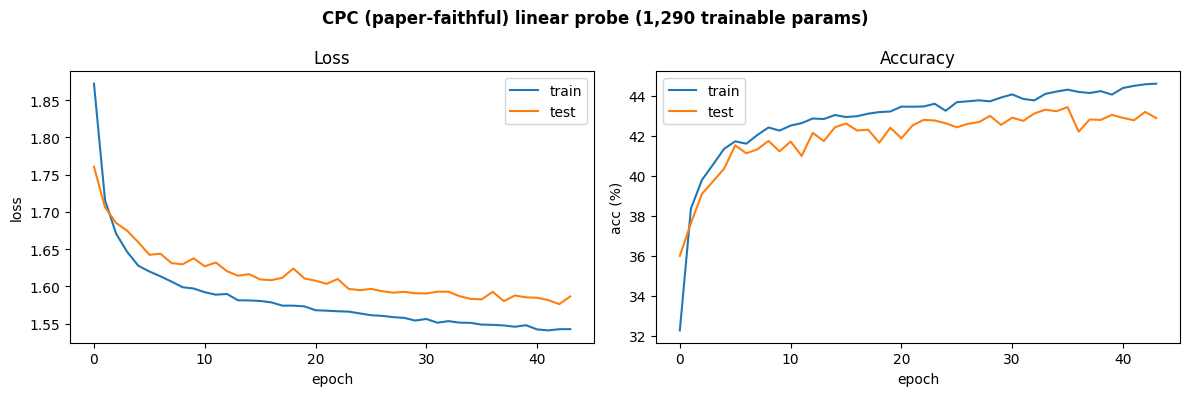

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(probe_train_losses, label='train'); ax1.plot(probe_test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in probe_train_accs], label='train'); ax2.plot([a*100 for a in probe_test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'CPC (paper-faithful) linear probe ({sum(p.numel() for p in probe.head.parameters()):,} trainable params)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Results

Plot 10 random predictions from the test set

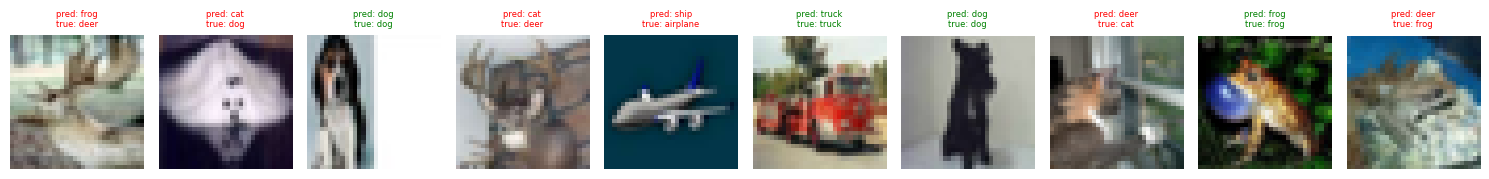

In [11]:
probe.eval()
classes = test_dataset.classes
indices = torch.randint(0, len(test_dataset), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = test_dataset[idx]
    with torch.no_grad():
        logits = probe(img.unsqueeze(0).to(device))
        pred   = logits.argmax(dim=1).item()
    axes[i].imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {classes[pred]}\ntrue: {classes[true_label]}",
                       fontsize=6, color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

---
# 5. Full fine-tune on CIFAR-10

Unfreeze the encoder, train everything end-to-end.

In [12]:
class FullFineTune(nn.Module):
    def __init__(self, encoder, num_classes, d_model):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Linear(d_model, num_classes)

    def forward(self, images):
        h = self.encoder(images)
        return self.head(h)


ft = FullFineTune(CPCEncoder(build_cpc_from_checkpoint()), NUM_CLASSES, D_MODEL).to(device)
print(f"trainable params : {sum(p.numel() for p in ft.parameters()):,}")

trainable params : 1,405,578


In [13]:
FT_LR = 1e-4

optimizer = torch.optim.AdamW(ft.parameters(), lr=FT_LR, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
ft_train_losses, ft_test_losses = [], []
ft_train_accs,   ft_test_accs   = [], []
ft_best_acc = 0.0

for epoch in range(1, FT_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(ft, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(ft, test_loader, criterion)
    ft_train_losses.append(tr_loss); ft_test_losses.append(te_loss)
    ft_train_accs.append(tr_acc);   ft_test_accs.append(te_acc)
    print(f"FT epoch {epoch:2d}/{FT_EPOCHS} | "
          f"train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > ft_best_acc:
        ft_best_acc = te_acc
        torch.save({'epoch': epoch, 'model': ft.state_dict(),
                    'train_losses': ft_train_losses, 'test_losses': ft_test_losses,
                    'train_accs':   ft_train_accs,   'test_accs':   ft_test_accs},
                   os.path.join(CKPT_DIR, 'cpc_ft_best.pt'))

    best_epoch = ft_test_accs.index(max(ft_test_accs))
    if (len(ft_test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print()
print(f"best test acc : {max(ft_test_accs)*100:.2f}%")
print(f"converged at  : epoch {ft_test_accs.index(max(ft_test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in ft_test_accs]):.3f} %/epoch")

FT epoch  1/60 | train 1.7798 35.8% | test 1.6545 40.1%
FT epoch  2/60 | train 1.5863 43.9% | test 1.5744 42.8%
FT epoch  3/60 | train 1.4996 47.3% | test 1.5385 43.6%
FT epoch  4/60 | train 1.4344 49.5% | test 1.4740 46.5%
FT epoch  5/60 | train 1.3918 50.9% | test 1.4249 48.6%
FT epoch  6/60 | train 1.3540 52.1% | test 1.4545 48.3%
FT epoch  7/60 | train 1.3197 53.6% | test 1.3666 50.4%
FT epoch  8/60 | train 1.2995 54.3% | test 1.3277 52.2%
FT epoch  9/60 | train 1.2782 54.8% | test 1.3402 52.0%
FT epoch 10/60 | train 1.2580 55.3% | test 1.2993 53.4%
FT epoch 11/60 | train 1.2408 56.3% | test 1.2692 55.1%
FT epoch 12/60 | train 1.2285 56.3% | test 1.2745 55.2%
FT epoch 13/60 | train 1.2142 57.1% | test 1.2792 53.7%
FT epoch 14/60 | train 1.1953 57.8% | test 1.2360 55.9%
FT epoch 15/60 | train 1.1854 58.2% | test 1.2601 55.2%
FT epoch 16/60 | train 1.1706 58.7% | test 1.2512 55.6%
FT epoch 17/60 | train 1.1635 58.8% | test 1.2260 56.8%
FT epoch 18/60 | train 1.1555 59.3% | test 1.211

## Curves

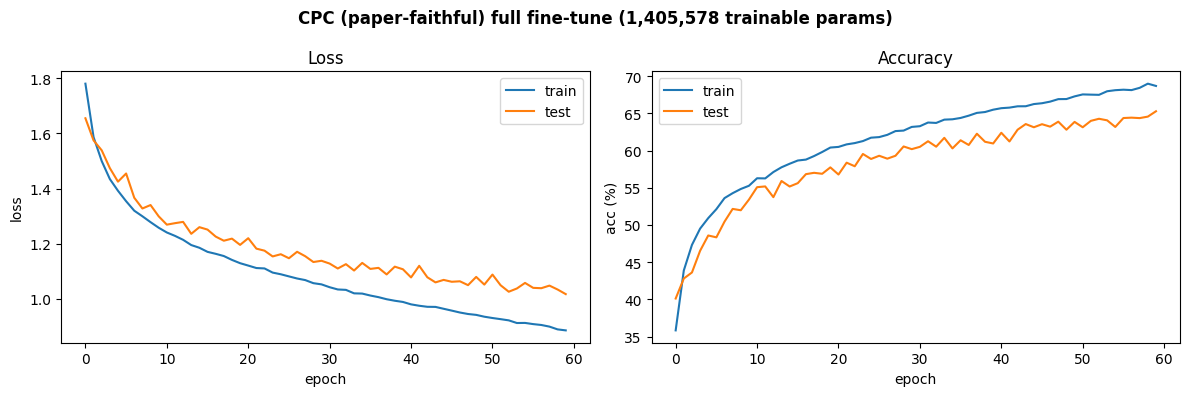

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ft_train_losses, label='train'); ax1.plot(ft_test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in ft_train_accs], label='train'); ax2.plot([a*100 for a in ft_test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'CPC (paper-faithful) full fine-tune ({sum(p.numel() for p in ft.parameters()):,} trainable params)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Results

Plot 10 random predictions from the test set

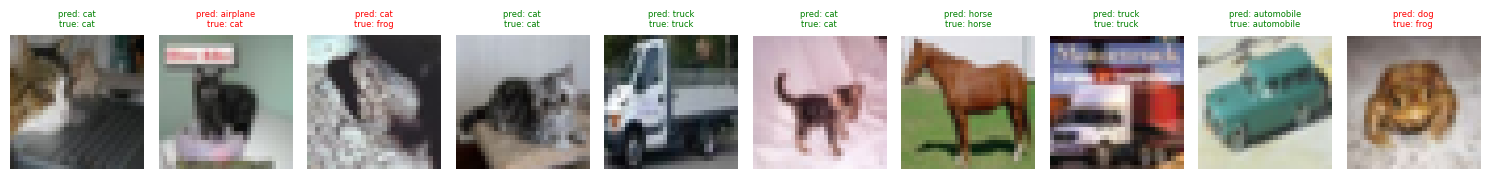

In [15]:
ft.eval()
classes = test_dataset.classes
indices = torch.randint(0, len(test_dataset), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = test_dataset[idx]
    with torch.no_grad():
        logits = ft(img.unsqueeze(0).to(device))
        pred   = logits.argmax(dim=1).item()
    axes[i].imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {classes[pred]}\ntrue: {classes[true_label]}",
                       fontsize=6, color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()